# 02 — Simplex Target Embeddings

Same two-phase structure as 01, but replaces the clustering loss with **fixed target
embeddings** placed at the vertices of a regular simplex.

**Why a simplex?** In 64 dimensions, a regular 9-simplex gives 10 vertices that
are all *maximally and equally* spaced from each other. The geometry is decided
before training starts — no moving centroids, no margin hyperparameters.

**Phase 1:** MSE loss pushing each sample's 64-dim embedding to its class's
fixed simplex vertex. The network must learn a mapping from pixels to exact points.

**Phase 2:** Freeze backbone, train 64→10 classifier (same as 01).

**Key question:** Does forcing embeddings to exact, pre-defined locations produce
cleaner separation than letting the network discover its own cluster geometry?

In [1]:
import sys
import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "..", "..", ".."))
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split
import matplotlib.pyplot as plt

from scripts.viz_export import ExperimentTracker

import numpy as np
from sklearn.metrics import silhouette_score

torch.manual_seed(42)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

print(f"PyTorch {torch.__version__}")
device = torch.device("cpu")

/Users/morgancooper/miniconda3/envs/nnpo/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


PyTorch 2.10.0


## 1. Load MNIST

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.1307,), (0.3081,)),
    transforms.Lambda(lambda x: x.view(-1)),
])

data_root = os.path.join(PROJECT_ROOT, "data")
full_train_dataset = datasets.MNIST(root=data_root, train=True, download=True, transform=transform)
test_dataset = datasets.MNIST(root=data_root, train=False, download=True, transform=transform)

train_dataset, val_dataset = random_split(
    full_train_dataset, [48000, 12000],
    generator=torch.Generator().manual_seed(42)
)

train_loader = DataLoader(train_dataset, batch_size=512, shuffle=True, generator=torch.Generator().manual_seed(0))
val_loader = DataLoader(val_dataset, batch_size=512, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=512, shuffle=False)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}, Test: {len(test_dataset)}")

Train: 48000, Val: 12000, Test: 10000


## 2. Define Model & Simplex Targets

In [3]:
# --- Hyperparameters ---
TARGET_SCALE = 5.0     # Radius of simplex vertices from origin
LR = 0.001
WEIGHT_DECAY = 1e-4    # L2 regularization (Adam)
L1_LAMBDA = 1e-4       # L1 regularization
DROPOUT = 0.3
EPOCHS_PHASE1 = 10
EPOCHS_PHASE2 = 10
CHECKPOINT_EVERY = 10   # Save checkpoint every N batches


def make_simplex_targets(num_classes=10, dim=64, scale=5.0):
    """Create vertices of a regular simplex in `dim` dimensions.

    All num_classes vertices are equidistant from each other and from the origin.
    Returns: [num_classes, dim] tensor.
    """
    # One-hot basis gives orthogonal directions, centering makes them equidistant
    targets = torch.eye(num_classes, dim)  # [10, 64]
    targets -= targets.mean(dim=0, keepdim=True)  # center at origin
    # Normalize each vertex to the same radius
    targets = targets / targets.norm(dim=1, keepdim=True) * scale
    return targets


class ClusterNet(nn.Module):
    """Two-phase model: clustering backbone + optional classifier head.

    Cumulative regularization stack: BN + LN + Dropout + L1 + L2
    """

    def __init__(self):
        super().__init__()
        self.fc1 = nn.Linear(784, 128)
        self.bn1 = nn.BatchNorm1d(128)
        self.drop1 = nn.Dropout(DROPOUT)
        self.fc2 = nn.Linear(128, 64)
        self.ln2 = nn.LayerNorm(64)
        self.drop2 = nn.Dropout(DROPOUT)
        self.fc3 = None  # Added in Phase 2

    def forward(self, x):
        x = self.drop1(torch.relu(self.bn1(self.fc1(x))))
        x = self.drop2(torch.relu(self.ln2(self.fc2(x))))
        if self.fc3 is not None:
            x = self.fc3(x)
        return x

    def freeze_backbone(self):
        for param in self.fc1.parameters():
            param.requires_grad = False
        for param in self.fc2.parameters():
            param.requires_grad = False
        for param in self.bn1.parameters():
            param.requires_grad = False
        for param in self.ln2.parameters():
            param.requires_grad = False

    def add_classifier(self):
        self.fc3 = nn.Linear(64, 10)


# Build targets and model
SIMPLEX_TARGETS = make_simplex_targets(num_classes=10, dim=64, scale=TARGET_SCALE).to(device)
model = ClusterNet().to(device)

# Verify: all pairwise distances should be equal
dists = torch.cdist(SIMPLEX_TARGETS.unsqueeze(0), SIMPLEX_TARGETS.unsqueeze(0)).squeeze(0)
mask = torch.triu(torch.ones(10, 10), diagonal=1).bool()
print(f"Target scale: {TARGET_SCALE}")
print(f"Pairwise distances — min: {dists[mask].min():.4f}, max: {dists[mask].max():.4f}, mean: {dists[mask].mean():.4f}")
print(f"L2 weight_decay: {WEIGHT_DECAY}, L1 lambda: {L1_LAMBDA}, Dropout: {DROPOUT}")
print(model)

Target scale: 5.0
Pairwise distances — min: 7.4536, max: 7.4536, mean: 7.4536
L2 weight_decay: 0.0001, L1 lambda: 0.0001, Dropout: 0.3
ClusterNet(
  (fc1): Linear(in_features=784, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (drop1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (ln2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
  (drop2): Dropout(p=0.3, inplace=False)
)


## 3. Pick Input Samples & Viz Samples

In [4]:
# 5 input samples: one per distinct digit (first 5 unique)
seen_labels = set()
five_images, five_labels = [], []
for img, label in full_train_dataset:
    if label not in seen_labels:
        five_images.append(img)
        five_labels.append(int(label))
        seen_labels.add(label)
    if len(seen_labels) == 5:
        break
five_images = torch.stack(five_images)
print(f"Input samples: labels={five_labels}, shape={five_images.shape}")

# 500 viz samples: 50 per class
viz_images, viz_labels = [], []
class_counts = {c: 0 for c in range(10)}
for img, label in full_train_dataset:
    label = int(label)
    if class_counts[label] < 50:
        viz_images.append(img)
        viz_labels.append(label)
        class_counts[label] += 1
    if all(v >= 50 for v in class_counts.values()):
        break
viz_images = torch.stack(viz_images)
print(f"Viz samples: {len(viz_labels)} total, shape={viz_images.shape}")

Input samples: labels=[5, 0, 4, 1, 9], shape=torch.Size([5, 784])
Viz samples: 500 total, shape=torch.Size([500, 784])


## 4. Phase 1 — Simplex Target Pre-Training

Train fc1 and fc2 with MSE loss pushing each sample's embedding to its class's
fixed simplex vertex. The targets never move — the network learns to hit exact points.

In [5]:
tracker1 = ExperimentTracker(
    run_id="simplex_pretrain",
    model_name="Simplex Pre-Train (Phase 1)",
    description="784\u2192128\u219264 backbone trained with MSE to fixed simplex targets",
    hyperparameters={
        "lr": LR, "batch_size": 512, "epochs": EPOCHS_PHASE1,
        "target_scale": TARGET_SCALE,
        "weight_decay": WEIGHT_DECAY, "l1_lambda": L1_LAMBDA, "dropout": DROPOUT,
        "phase": 1,
    },
    model=model,
)

tracker1.track("input", size=784)
tracker1.track("hidden_1", model.fc1, size=128)
tracker1.track("hidden_2", model.fc2, size=64)

tracker1.set_input_samples(five_images, five_labels)
tracker1.set_viz_samples(viz_images, viz_labels)
tracker1.enable_gradient_capture()

# Criterion for loss landscape: MSE to simplex targets
def simplex_criterion(embeddings, labels):
    return ((embeddings - SIMPLEX_TARGETS[labels]) ** 2).sum(dim=1).mean()

tracker1.enable_loss_landscape()

ExperimentTracker: will write to /Users/morgancooper/NeuralNetworkProjectionOperator/scripts/../experimentation/runs/simplex_pretrain_v4


In [6]:
optimizer = optim.Adam(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)
mse = nn.MSELoss()

def evaluate_simplex(loader):
    model.eval()
    total_mse = 0.0
    n = 0
    with torch.no_grad():
        for x, y in loader:
            emb = model(x)
            targets = SIMPLEX_TARGETS[y]
            total_mse += ((emb - targets) ** 2).sum(dim=1).mean().item()
            n += 1
    return total_mse / n

history1 = {"epoch": [], "train_mse": [], "val_mse": []}
step = 0
global_batch = 0

for epoch in range(EPOCHS_PHASE1):
    model.train()
    running_mse = 0.0

    for batch_idx, (batch_x, batch_y) in enumerate(train_loader):
        optimizer.zero_grad()
        embeddings = model(batch_x)
        targets = SIMPLEX_TARGETS[batch_y]
        l1_norm = sum(p.abs().sum() for p in model.parameters())
        loss = mse(embeddings, targets) + L1_LAMBDA * l1_norm

        loss.backward()
        tracker1.capture_gradients()
        optimizer.step()

        running_mse += mse(embeddings, targets).item()
        global_batch += 1

        if global_batch % CHECKPOINT_EVERY == 0:
            val_mse = evaluate_simplex(val_loader)
            tracker1.compute_loss_landscape(batch_x, batch_y, simplex_criterion)
            tracker1.save_checkpoint(step=step, epoch=epoch, metrics={
                "train_loss": running_mse / (batch_idx + 1),
                "val_loss": val_mse,
            })
            step += 1
            model.train()

    avg_mse = running_mse / len(train_loader)
    print(f"Epoch {epoch}: mse={avg_mse:.4f}")

    val_mse = evaluate_simplex(val_loader)
    history1["epoch"].append(epoch)
    history1["train_mse"].append(avg_mse)
    history1["val_mse"].append(val_mse)

print(f"\nPhase 1 complete \u2014 {step} checkpoints saved")

  step_000.json (epoch=0, loss=30.2828, acc=0.0000, size=5.0MB)
  step_001.json (epoch=0, loss=23.1725, acc=0.0000, size=5.0MB)
  step_002.json (epoch=0, loss=20.0809, acc=0.0000, size=5.0MB)
  step_003.json (epoch=0, loss=17.7519, acc=0.0000, size=5.0MB)
  step_004.json (epoch=0, loss=15.8925, acc=0.0000, size=5.0MB)
  step_005.json (epoch=0, loss=14.5199, acc=0.0000, size=5.0MB)
  step_006.json (epoch=0, loss=13.4440, acc=0.0000, size=5.0MB)
  step_007.json (epoch=0, loss=12.5538, acc=0.0000, size=5.0MB)
  step_008.json (epoch=0, loss=11.8150, acc=0.0000, size=5.0MB)
Epoch 0: mse=0.4477
  step_009.json (epoch=1, loss=11.2072, acc=0.0000, size=5.0MB)
  step_010.json (epoch=1, loss=10.7594, acc=0.0000, size=5.0MB)
  step_011.json (epoch=1, loss=10.3568, acc=0.0000, size=5.0MB)
  step_012.json (epoch=1, loss=10.0258, acc=0.0000, size=5.0MB)
  step_013.json (epoch=1, loss=9.6703, acc=0.0000, size=5.0MB)
  step_014.json (epoch=1, loss=9.4368, acc=0.0000, size=5.1MB)
  step_015.json (epoch

### Phase 1 Training Curves

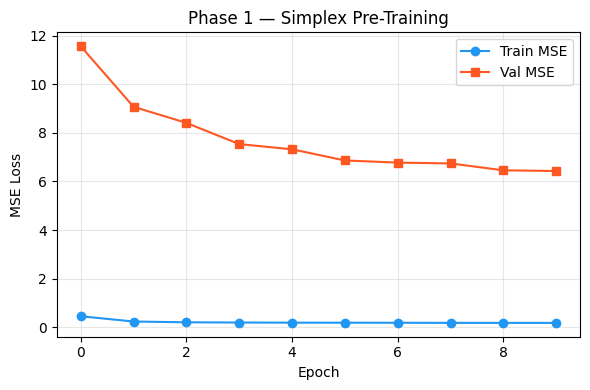

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))
epochs = history1["epoch"]
ax.plot(epochs, history1["train_mse"], "o-", label="Train MSE", color="#2196F3")
ax.plot(epochs, history1["val_mse"], "s-", label="Val MSE", color="#FF5722")
ax.set_xlabel("Epoch"); ax.set_ylabel("MSE Loss")
ax.set_title("Phase 1 — Simplex Pre-Training"); ax.legend(); ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

In [8]:
tracker1.finalize()
print(f"Phase 1 run: {tracker1.run_id}")

# Save backbone for reuse in other notebooks
save_dir = os.path.join(PROJECT_ROOT, "experimentation", "02_clustering_pretrain", "checkpoints")
os.makedirs(save_dir, exist_ok=True)

save_path = os.path.join(save_dir, "simplex_backbone.pt")
torch.save({
    "model_state_dict": model.state_dict(),
    "simplex_targets": SIMPLEX_TARGETS,
    "hyperparameters": {
        "target_scale": TARGET_SCALE,
        "lr": LR, "weight_decay": WEIGHT_DECAY, "l1_lambda": L1_LAMBDA, "dropout": DROPOUT,
        "epochs": EPOCHS_PHASE1,
    },
    "architecture": {
        "fc1": [784, 128],  # [in, out]
        "fc2": [128, 64],
    },
}, save_path)
print(f"Saved backbone: {save_path}")

Finalized run 'simplex_pretrain_v4' with 94 checkpoints
Phase 1 run: simplex_pretrain_v4
Saved backbone: /Users/morgancooper/NeuralNetworkProjectionOperator/experimentation/02_clustering_pretrain/checkpoints/simplex_backbone.pt


## 5. Phase 2 — Classification Fine-Tuning

Freeze the backbone and train a linear classifier on the simplex-shaped features.
If Phase 1 worked well, the 10 classes should already be perfectly linearly separable.

In [9]:
# Freeze backbone and add classification head
model.freeze_backbone()
model.add_classifier()
model = model.to(device)

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"Frozen backbone, added fc3 (64\u219210)")
print(f"Trainable: {trainable:,} / {total:,} params")

tracker2 = ExperimentTracker(
    run_id="simplex_classify",
    model_name="Simplex\u2192Classify (Phase 2)",
    description="Classification head on frozen simplex-trained backbone",
    hyperparameters={
        "lr": LR, "batch_size": 512, "epochs": EPOCHS_PHASE2,
        "weight_decay": WEIGHT_DECAY, "l1_lambda": L1_LAMBDA, "dropout": DROPOUT,
        "frozen_layers": ["fc1", "bn1", "fc2", "ln2"],
        "phase": 2,
    },
    model=model,
)

tracker2.track("input", size=784)
tracker2.track("hidden_1", model.fc1, size=128)
tracker2.track("hidden_2", model.fc2, size=64)
tracker2.track("output", model.fc3, size=10)

tracker2.set_input_samples(five_images, five_labels)
tracker2.set_viz_samples(viz_images, viz_labels)
tracker2.enable_gradient_capture()
tracker2.enable_loss_landscape()

Frozen backbone, added fc3 (64→10)
Trainable: 650 / 109,770 params
ExperimentTracker: will write to /Users/morgancooper/NeuralNetworkProjectionOperator/scripts/../experimentation/runs/simplex_classify_v4


In [10]:
criterion = nn.CrossEntropyLoss()
optimizer2 = optim.Adam(model.fc3.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

def evaluate(loader):
    model.eval()
    total_loss = correct = total = 0
    with torch.no_grad():
        for x, y in loader:
            out = model(x)
            total_loss += criterion(out, y).item() * y.size(0)
            correct += (out.argmax(1) == y).sum().item()
            total += y.size(0)
    return total_loss / total, correct / total

history2 = {"epoch": [], "train_loss": [], "val_loss": [], "val_accuracy": [], "test_accuracy": []}
step2 = 0
global_batch2 = 0

for epoch in range(EPOCHS_PHASE2):
    model.train()
    running_loss = 0.0

    for batch_idx, (batch_x, batch_y) in enumerate(train_loader):
        optimizer2.zero_grad()
        output = model(batch_x)
        l1_norm = sum(p.abs().sum() for p in model.fc3.parameters())
        loss = criterion(output, batch_y) + L1_LAMBDA * l1_norm
        loss.backward()
        tracker2.capture_gradients()
        optimizer2.step()
        running_loss += loss.item()
        global_batch2 += 1

        if global_batch2 % CHECKPOINT_EVERY == 0:
            val_loss, val_acc = evaluate(val_loader)
            _, test_acc = evaluate(test_loader)
            tracker2.compute_loss_landscape(batch_x, batch_y, criterion)
            tracker2.save_checkpoint(step=step2, epoch=epoch, metrics={
                "train_loss": running_loss / (batch_idx + 1),
                "val_loss": val_loss,
                "val_accuracy": val_acc,
                "test_accuracy": test_acc,
            })
            step2 += 1
            model.train()

    print(f"Epoch {epoch}: loss={running_loss / len(train_loader):.4f}")

    val_loss, val_acc = evaluate(val_loader)
    _, test_acc = evaluate(test_loader)
    history2["epoch"].append(epoch)
    history2["train_loss"].append(running_loss / len(train_loader))
    history2["val_loss"].append(val_loss)
    history2["val_accuracy"].append(val_acc)
    history2["test_accuracy"].append(test_acc)

print(f"\nPhase 2 complete \u2014 {step2} checkpoints saved")

  step_000.json (epoch=0, loss=2.2945, acc=0.0877, size=5.1MB)
  step_001.json (epoch=0, loss=2.2401, acc=0.0908, size=5.1MB)
  step_002.json (epoch=0, loss=2.1866, acc=0.3057, size=5.1MB)
  step_003.json (epoch=0, loss=2.1335, acc=0.4308, size=5.1MB)
  step_004.json (epoch=0, loss=2.0810, acc=0.4474, size=5.1MB)
  step_005.json (epoch=0, loss=2.0296, acc=0.4577, size=5.1MB)
  step_006.json (epoch=0, loss=1.9785, acc=0.5375, size=5.1MB)
  step_007.json (epoch=0, loss=1.9291, acc=0.5502, size=5.1MB)
  step_008.json (epoch=0, loss=1.8807, acc=0.5577, size=5.1MB)
Epoch 0: loss=2.1254
  step_009.json (epoch=1, loss=1.8322, acc=0.8036, size=5.1MB)
  step_010.json (epoch=1, loss=1.7846, acc=0.8764, size=5.1MB)
  step_011.json (epoch=1, loss=1.7378, acc=0.9511, size=5.1MB)
  step_012.json (epoch=1, loss=1.6929, acc=0.9528, size=5.1MB)
  step_013.json (epoch=1, loss=1.6488, acc=0.9540, size=5.1MB)
  step_014.json (epoch=1, loss=1.6061, acc=0.9552, size=5.1MB)
  step_015.json (epoch=1, loss=1.5

### Phase 2 Training Curves

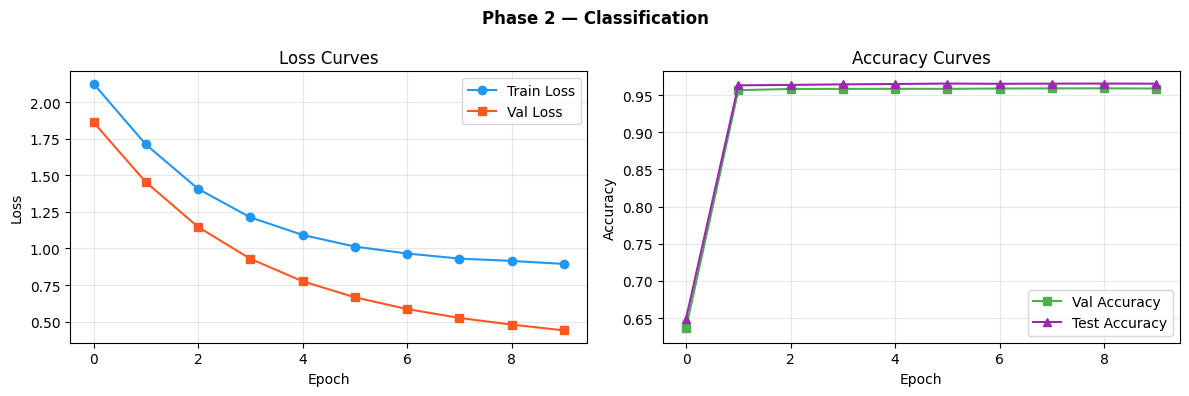

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
epochs = history2["epoch"]

ax = axes[0]
ax.plot(epochs, history2["train_loss"], "o-", label="Train Loss", color="#2196F3")
ax.plot(epochs, history2["val_loss"], "s-", label="Val Loss", color="#FF5722")
ax.set_xlabel("Epoch"); ax.set_ylabel("Loss")
ax.set_title("Loss Curves"); ax.legend(); ax.grid(True, alpha=0.3)

ax = axes[1]
ax.plot(epochs, history2["val_accuracy"], "s-", label="Val Accuracy", color="#4CAF50")
ax.plot(epochs, history2["test_accuracy"], "^-", label="Test Accuracy", color="#9C27B0")
ax.set_xlabel("Epoch"); ax.set_ylabel("Accuracy")
ax.set_title("Accuracy Curves"); ax.legend(); ax.grid(True, alpha=0.3)
ax.set_ylim(bottom=max(0, min(history2["val_accuracy"]) - 0.02))

plt.suptitle("Phase 2 — Classification", fontweight="bold")
plt.tight_layout()
plt.show()

In [12]:
tracker2.finalize()
print(f"Phase 2 run: {tracker2.run_id}")

# Final evaluation
val_loss, val_acc = evaluate(val_loader)
test_loss, test_acc = evaluate(test_loader)
print(f"\nFinal val accuracy:  {val_acc:.4f}")
print(f"Final test accuracy: {test_acc:.4f}")

# Silhouette score on test set hidden activations
hidden_acts, hidden_labels = [], []
hook_out = {}
def _hook(module, inp, out):
    hook_out['act'] = inp[0].detach()
handle = model.fc3.register_forward_hook(_hook)
model.eval()
with torch.no_grad():
    for x, y in test_loader:
        model(x)
        hidden_acts.append(hook_out['act'].numpy())
        hidden_labels.append(y.numpy())
handle.remove()

X_hidden = np.concatenate(hidden_acts)
y_hidden = np.concatenate(hidden_labels)
n_sil = min(5000, len(X_hidden))
idx = np.random.RandomState(42).choice(len(X_hidden), n_sil, replace=False)
sil = silhouette_score(X_hidden[idx], y_hidden[idx])
print(f"\nSilhouette score (test, {X_hidden.shape[1]}D hidden): {sil:.4f}")

# Save full model checkpoint (backbone + fc3) for error analysis
ckpt_dir = os.path.join(PROJECT_ROOT, "experimentation", "02_clustering_pretrain", "checkpoints")
os.makedirs(ckpt_dir, exist_ok=True)
torch.save(model.state_dict(), os.path.join(ckpt_dir, "simplex_classify.pt"))
print(f"Saved checkpoint to {ckpt_dir}/simplex_classify.pt")

Finalized run 'simplex_classify_v4' with 94 checkpoints
Phase 2 run: simplex_classify_v4

Final val accuracy:  0.9589
Final test accuracy: 0.9654

Silhouette score (test, 64D hidden): 0.7623
Saved checkpoint to /Users/morgancooper/NeuralNetworkProjectionOperator/experimentation/02_clustering_pretrain/checkpoints/simplex_classify.pt
